# LangGraph Swarm Agents

## 학습 목표
- LangGraph + Swarm의 개념과 장점 이해
- 멀티 에이전트 패턴 비교 (Tool-calling, Swarm)
- Swarm 핵심 API 학습 및 실습
- 에이전트 간 핸드오프(handoff) 구현


## LangGraph + Swarm이란?
- [LangGraph Swarm 공식 문서](https://reference.langchain.com/python/langgraph/swarm/)


### Swarm의 개념
**Swarm**은 여러 에이전트가 협업하여 복잡한 작업을 수행하는 멀티 에이전트 시스템입니다.

### 핵심 특징
1. **경량화된 멀티 에이전트 오케스트레이션**: OpenAI의 Swarm 패턴에서 영감을 받음
2. **동적 핸드오프**: 에이전트 간 제어권을 동적으로 전환
3. **컨텍스트 유지**: 대화 상태와 히스토리를 유지하면서 에이전트 전환
4. **도구 기반 전환**: 특수한 핸드오프 도구를 통해 에이전트 간 이동


## 단일 에이전트 vs 멀티 에이전트


### 단일 에이전트 (Single Agent)
```
사용자 → Agent → 도구들 → 응답
```
**장점:**
- 간단한 구조
- 빠른 응답
- 관리 용이

**단점:**
- 복잡한 작업 처리 어려움
- 전문화된 작업 처리 제한
- 컨텍스트 관리 복잡


### 멀티 에이전트 (Multi-Agent)
```
사용자 → 조정자 → Agent1 (전문가1)
              ↓
              → Agent2 (전문가2)
              ↓
              → Agent3 (전문가3)
```
**장점:**
- 각 에이전트가 특정 도메인 전문화
- 복잡한 워크플로우 처리
- 병렬 처리 가능

**단점:**
- 복잡한 오케스트레이션 필요
- 디버깅 어려움
- 오버헤드 증가


## 멀티 에이전트 패턴 비교

### Tool-Calling 패턴
- **구조**: 단일 에이전트가 여러 도구를 호출
- **제어**: 중앙 집중식
- **용도**: 도구 기반 작업 자동화
```python
agent → [tool1, tool2, tool3, ...]
```

### Swarm 패턴
- **구조**: 에이전트 간 동적 핸드오프
- **제어**: 분산형, 각 에이전트가 다음 에이전트 결정
- **용도**: 유연한 대화 흐름, 복잡한 협업
```python
Agent A ←→ Agent B
    ↓         ↓
Agent C ←→ Agent D
```

## Swarm 핵심 API

### 주요 컴포넌트

#### 1. `create_swarm()`
멀티 에이전트 Swarm을 생성하는 메인 함수

```python
create_swarm(
    agents: list[Pregel],           # 에이전트 리스트
    default_active_agent: str,       # 기본 활성 에이전트 이름
    state_schema: StateSchemaType,   # 상태 스키마 (기본: SwarmState)
    context_schema: type[Any] | None # 컨텍스트 스키마
) -> StateGraph
```

#### 2. `SwarmState`
Swarm의 상태를 관리하는 스키마
- `MessagesState`를 상속
- 메시지 히스토리와 현재 활성 에이전트 정보 포함

#### 3. `create_handoff_tool()`
에이전트 간 제어권 전환 도구 생성

```python
create_handoff_tool(
    agent_name: str,        # 전환할 에이전트 이름
    name: str | None,       # 도구 이름 (옵션)
    description: str | None # 도구 설명 (옵션)
) -> BaseTool
```

#### 4. `add_active_agent_router()`
StateGraph에 활성 에이전트 라우터 추가

```python
add_active_agent_router(
    builder: StateGraph,
    route_to: list[str],           # 라우팅할 에이전트 이름 리스트
    default_active_agent: str      # 기본 활성 에이전트
) -> StateGraph
```

# 실습 예제 

## 실습 1: LLM 초기화


In [1]:
from dotenv import load_dotenv 

load_dotenv()

True

- [OpenAI(ChatGPT) Model](https://platform.openai.com/docs/models)
- [모델별 금액](https://platform.openai.com/docs/pricing) 

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

## 실습 2: 에이전트별 전문 도구 정의

각 에이전트가 사용할 전문 도구들을 정의합니다.

### 계산 전담 에이전트 도구

In [3]:
from langchain_core.tools import tool

@tool
def add_numbers(a: float, b: float) -> float:
    """두 숫자를 더합니다."""
    return a + b

@tool
def subtract_numbers(a: float, b: float) -> float:
    """두 숫자를 뺍니다."""
    return a - b

@tool
def multiply_numbers(a: float, b: float) -> float:
    """두 숫자를 곱합니다."""
    return a * b

@tool
def divide_numbers(a: float, b: float) -> float:
    """두 숫자를 나눕니다."""
    if b == 0:
        return "0으로 나눌 수 없습니다."
    return a / b



> 도구 테스트

In [4]:
result = add_numbers.invoke({
    "a":5, "b":3
})
print(f"5 + 3 = {result}")

5 + 3 = 8.0


> 도구 목록

In [5]:
calculator_tools = [add_numbers, subtract_numbers, multiply_numbers, divide_numbers]

print("계산 도구 정의 완료")
for calculator in calculator_tools:
    print("=" * 50)
    print(f"Tool 이름: {calculator.name}")
    print(f"Tool 설명: {calculator.description}")
    print(f"Tool 인풋 파라미터: {calculator.args}")
    print(f"Tool return_direct: {calculator.return_direct}")

계산 도구 정의 완료
Tool 이름: add_numbers
Tool 설명: 두 숫자를 더합니다.
Tool 인풋 파라미터: {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}
Tool return_direct: False
Tool 이름: subtract_numbers
Tool 설명: 두 숫자를 뺍니다.
Tool 인풋 파라미터: {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}
Tool return_direct: False
Tool 이름: multiply_numbers
Tool 설명: 두 숫자를 곱합니다.
Tool 인풋 파라미터: {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}
Tool return_direct: False
Tool 이름: divide_numbers
Tool 설명: 두 숫자를 나눕니다.
Tool 인풋 파라미터: {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}
Tool return_direct: False


### 텍스트 처리 전담 에이전트 도구

In [6]:
from langchain_core.tools import tool

@tool
def count_words(text: str) -> int:
    """텍스트의 단어 수를 세어 반환합니다."""
    return len(text.split())

@tool
def reverse_text(text: str) -> str:
    """텍스트를 역순으로 뒤집습니다."""
    return text[::-1]

@tool
def to_uppercase(text: str) -> str:
    """텍스트를 대문자로 변환합니다."""
    return text.upper()

@tool
def to_lowercase(text: str) -> str:
    """텍스트를 소문자로 변환합니다."""
    return text.lower()

@tool
def count_characters(text: str) -> int:
    """텍스트의 문자 수를 세어 반환합니다 (공백 포함)."""
    return len(text)


> 도구 테스트

In [7]:
result = count_words.invoke({
    "text":"Hello World"
})
print(f"Hello World의 단어 수 = {result}")

Hello World의 단어 수 = 2


> 도구 목록

In [8]:
# 텍스트 처리 도구 목록
text_tools = [count_words, reverse_text, to_uppercase, to_lowercase, count_characters]

print("텍스트 처리 도구 정의 완료")
for text in text_tools:
    print("=" * 50)
    print(f"Tool 이름: {text.name}")
    print(f"Tool 설명: {text.description}")
    print(f"Tool 인풋 파라미터: {text.args}")
    print(f"Tool return_direct: {text.return_direct}")

텍스트 처리 도구 정의 완료
Tool 이름: count_words
Tool 설명: 텍스트의 단어 수를 세어 반환합니다.
Tool 인풋 파라미터: {'text': {'title': 'Text', 'type': 'string'}}
Tool return_direct: False
Tool 이름: reverse_text
Tool 설명: 텍스트를 역순으로 뒤집습니다.
Tool 인풋 파라미터: {'text': {'title': 'Text', 'type': 'string'}}
Tool return_direct: False
Tool 이름: to_uppercase
Tool 설명: 텍스트를 대문자로 변환합니다.
Tool 인풋 파라미터: {'text': {'title': 'Text', 'type': 'string'}}
Tool return_direct: False
Tool 이름: to_lowercase
Tool 설명: 텍스트를 소문자로 변환합니다.
Tool 인풋 파라미터: {'text': {'title': 'Text', 'type': 'string'}}
Tool return_direct: False
Tool 이름: count_characters
Tool 설명: 텍스트의 문자 수를 세어 반환합니다 (공백 포함).
Tool 인풋 파라미터: {'text': {'title': 'Text', 'type': 'string'}}
Tool return_direct: False


### 검색 전담 에이전트 도구

In [9]:
from langchain_core.tools import tool

# 간단한 데이터베이스 시뮬레이션
knowledge_base = {
    "python": "Python은 1991년 귀도 반 로섬이 만든 인터프리터 프로그래밍 언어입니다.",
    "langgraph": "LangGraph는 LLM 애플리케이션의 복잡한 워크플로우를 구축하기 위한 프레임워크입니다.",
    "swarm": "Swarm은 여러 에이전트가 협업하여 복잡한 작업을 수행하는 멀티 에이전트 시스템입니다.",
    "ai": "인공지능(AI)은 인간의 학습능력, 추론능력, 지각능력 등을 컴퓨터 프로그램으로 실현한 기술입니다.",
    "llm": "대규모 언어 모델(LLM)은 방대한 텍스트 데이터로 학습된 인공지능 모델입니다."
}

@tool
def search_knowledge(query: str) -> str:
    """지식 베이스에서 정보를 검색합니다."""
    query_lower = query.lower()
    for key, value in knowledge_base.items():
        if key in query_lower:
            return f"검색 결과: {value}"
    return f"'{query}'에 대한 정보를 찾을 수 없습니다."

@tool
def list_topics() -> str:
    """지식 베이스에 있는 모든 주제를 나열합니다."""
    topics = ", ".join(knowledge_base.keys())
    return f"사용 가능한 주제: {topics}"

@tool
def add_knowledge(topic: str, content: str) -> str:
    """지식 베이스에 새로운 정보를 추가합니다."""
    knowledge_base[topic.lower()] = content
    return f"'{topic}' 주제가 추가되었습니다."
    

> 도구 테스트

In [10]:
result = search_knowledge.invoke({
    "query":"langgraph"
})
print(f"langgraph란?\n{result}")

langgraph란?
검색 결과: LangGraph는 LLM 애플리케이션의 복잡한 워크플로우를 구축하기 위한 프레임워크입니다.


> 도구 목록

In [11]:
# 검색 도구 목록
search_tools = [search_knowledge, list_topics, add_knowledge]

print("검색 도구 정의 완료")
for search in search_tools:
    print("=" * 50)
    print(f"Tool 이름: {search.name}")
    print(f"Tool 설명: {search.description}")
    print(f"Tool 인풋 파라미터: {search.args}")
    print(f"Tool return_direct: {search.return_direct}")

검색 도구 정의 완료
Tool 이름: search_knowledge
Tool 설명: 지식 베이스에서 정보를 검색합니다.
Tool 인풋 파라미터: {'query': {'title': 'Query', 'type': 'string'}}
Tool return_direct: False
Tool 이름: list_topics
Tool 설명: 지식 베이스에 있는 모든 주제를 나열합니다.
Tool 인풋 파라미터: {}
Tool return_direct: False
Tool 이름: add_knowledge
Tool 설명: 지식 베이스에 새로운 정보를 추가합니다.
Tool 인풋 파라미터: {'topic': {'title': 'Topic', 'type': 'string'}, 'content': {'title': 'Content', 'type': 'string'}}
Tool return_direct: False


## 실습 3: Handoff 도구 설정

다른 에이전트로 작업을 넘길 수 있는 핸드오프 도구를 추가합니다.

### handoff_to_calculator

In [12]:
from langgraph_swarm import create_handoff_tool

handoff_to_calculator = create_handoff_tool(
    agent_name="calculator_agent",
    name="transfer_to_calculator",
    description="계산이 필요할 때 계산기 에이전트로 작업을 전달합니다. 덧셈, 뺄셈, 곱셈, 나눗셈 등의 수학 연산에 사용합니다."
)


### handoff_to_text

In [13]:
handoff_to_text = create_handoff_tool(
    agent_name="text_agent",
    name="transfer_to_text",
    description="텍스트 처리가 필요할 때 텍스트 에이전트로 작업을 전달합니다. 단어 수 세기, 대소문자 변환, 텍스트 뒤집기 등에 사용합니다."
)


### handoff_to_search

In [14]:
handoff_to_search = create_handoff_tool(
    agent_name="search_agent",
    name="transfer_to_search",
    description="정보 검색이 필요할 때 검색 에이전트로 작업을 전달합니다. 지식 베이스에서 정보를 찾거나 주제를 나열할 때 사용합니다."
)


### handoff_to_coordinator

In [15]:
handoff_to_coordinator = create_handoff_tool(
    agent_name="coordinator_agent",
    name="transfer_to_coordinator",
    description="작업을 완료했거나 다른 에이전트가 필요할 때 조정자 에이전트로 돌아갑니다."
)


## 실습 4: 전문 에이전트 생성 

### 조정자 에이전트 (Coordinator)

In [16]:
from langchain.agents import create_agent

# - 사용자의 요청을 받고 적절한 전문 에이전트에게 작업을 분배
coordinator_agent = create_agent(
    name = "coordinator_agent",
    model=llm,
    tools=[handoff_to_calculator, handoff_to_text, handoff_to_search],
    system_prompt="""
    당신은 조정자 에이전트입니다.
    사용자의 요청을 분석하고 적절한 전문 에이전트에게 작업을 전달하는 역할을 합니다.

    - 계산이 필요하면 → calculator_agent로 전달
    - 텍스트 처리가 필요하면 → text_agent로 전달  
    - 정보 검색이 필요하면 → search_agent로 전달

    각 에이전트의 역할을 파악하고 가장 적합한 에이전트를 선택하세요."""
)


### 계산기 에이전트 (Calculator)

In [17]:
# - 수학 연산 전담
calculator_agent = create_agent(
    name = "calculator_agent",
    model=llm,
    tools=calculator_tools + [handoff_to_coordinator],
    system_prompt="""
    당신은 계산 전문 에이전트입니다.
    수학적 계산(덧셈, 뺄셈, 곱셈, 나눗셈)을 수행하는 것이 당신의 역할입니다.

    계산을 완료하면 반드시 transfer_to_coordinator를 사용하여 조정자에게 결과를 보고하세요."""
)


### 텍스트 처리 에이전트 (Text Processor)

In [18]:
# - 텍스트 변환 및 분석 전담
text_agent = create_agent(
    name = "text_agent",
    model=llm,
    tools=text_tools + [handoff_to_coordinator],
    system_prompt="""당신은 텍스트 처리 전문 에이전트입니다.
    텍스트 관련 작업(단어 수 세기, 대소문자 변환, 텍스트 뒤집기 등)을 수행하는 것이 당신의 역할입니다.

    작업을 완료하면 반드시 transfer_to_coordinator를 사용하여 조정자에게 결과를 보고하세요."""
)


### 검색 에이전트 (Search Agent)

In [19]:
# - 정보 검색 및 지식 관리 전담
search_agent = create_agent(
    name = "search_agent",
    model=llm,
    tools=search_tools + [handoff_to_coordinator],
    system_prompt="""당신은 검색 전문 에이전트입니다.
    지식 베이스에서 정보를 검색하고 관리하는 것이 당신의 역할입니다.

    검색을 완료하면 반드시 transfer_to_coordinator를 사용하여 조정자에게 결과를 보고하세요."""
)


## 실습 5: Swarm 시스템 구성 

### Swarm 생성

In [20]:
from langgraph_swarm import create_swarm

# Swarm 생성
swarm = create_swarm(
    agents=[
        coordinator_agent,
        calculator_agent,
        text_agent,
        search_agent
    ],
    default_active_agent="coordinator_agent"  # 기본 시작 에이전트
)

### Swarm 컴파일

In [21]:
# Swarm 컴파일
swarm_graph = swarm.compile()

print("Swarm 시스템 구성 완료")
print("시스템 구조:")
print("   coordinator_agent (조정자)")
print("   ├─ calculator_agent (계산)")
print("   ├─ text_agent (텍스트)")
print("   └─ search_agent (검색)")
print("조정자가 사용자 요청을 분석하여 적절한 전문 에이전트에게 작업을 분배합니다.")

Swarm 시스템 구성 완료
시스템 구조:
   coordinator_agent (조정자)
   ├─ calculator_agent (계산)
   ├─ text_agent (텍스트)
   └─ search_agent (검색)
조정자가 사용자 요청을 분석하여 적절한 전문 에이전트에게 작업을 분배합니다.


### Display

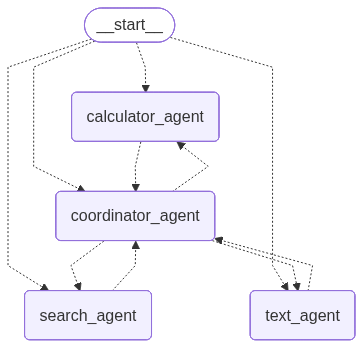

In [22]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            swarm_graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 테스트 

### 테스트를 위한 헬퍼 함수

In [23]:
# 테스트를 위한 헬퍼 함수
def run_swarm(user_message: str):
    """Swarm에 메시지를 전달하고 결과를 출력하는 헬퍼 함수"""
    print(f"\n{'='*70}")
    print(f"사용자: {user_message}")
    print(f"{'='*70}\n")
    
    result = swarm_graph.invoke({
        "messages": [{"role": "user", "content": user_message}]
    })
    
    # 에이전트 전환 과정 출력
    print("에이전트 전환 과정:")
    for i, msg in enumerate(result["messages"], 1):
        if hasattr(msg, 'name') and msg.name:
            print(f"   {i}. [{msg.name}]")
        elif msg.type == "ai":
            print(f"   {i}. [AI 응답]")
    
    # 최종 응답 출력
    final_message = result["messages"][-1]
    print(f"최종 응답:")
    print(f"   {final_message.content}")
    print('='*70)
    
    return result

print("헬퍼 함수 준비 완료")

헬퍼 함수 준비 완료


### 테스트 1: 계산 작업 (Calculator Agent)

In [24]:
result_calculator = run_swarm("123과 456을 더해줘")


사용자: 123과 456을 더해줘

에이전트 전환 과정:
   2. [AI 응답]
   3. [transfer_to_calculator]
   4. [AI 응답]
   5. [add_numbers]
   6. [AI 응답]
   7. [transfer_to_coordinator]
   8. [AI 응답]
최종 응답:
   123과 456의 합은 579입니다.

다른 계산이 필요하신가요?


In [25]:
result_calculator

{'messages': [HumanMessage(content='123과 456을 더해줘', additional_kwargs={}, response_metadata={}, id='20855d7f-c234-4c8e-b6dc-15c08d933407'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 277, 'prompt_tokens': 367, 'total_tokens': 644, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 256, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Ckh7ZN1wjGvuP2UAiKHKhj3eL5aFZ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b00cb-48c0-7d30-b28d-9e9187e09549-0', tool_calls=[{'name': 'transfer_to_calculator', 'args': {}, 'id': 'call_bqFBDOYf3OXNvZZpyMjgu26a', 'type': 'tool_call'}], usage_metadata={'input_tokens': 367, 'output_tokens': 277, 'total_tokens': 644, 'input_token_

#### [Langsmith](https://smith.langchain.com/)

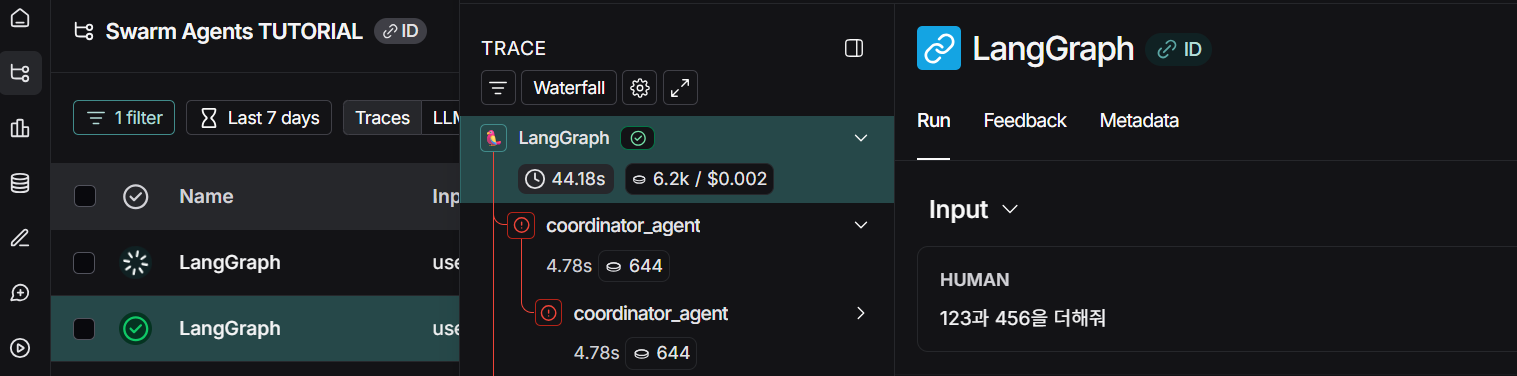

### 테스트 2: 텍스트 처리 작업 (Text Agent)

In [26]:
result_text = run_swarm("'Hello World'라는 텍스트를 대문자로 변환하고 단어 수를 세어줘")


사용자: 'Hello World'라는 텍스트를 대문자로 변환하고 단어 수를 세어줘

에이전트 전환 과정:
   2. [AI 응답]
   3. [transfer_to_text]
   4. [AI 응답]
   5. [to_uppercase]
   6. [count_words]
   7. [AI 응답]
최종 응답:
   대문자 변환 결과: HELLO WORLD
단어 수: 2

(조정자에게 결과를 보고합니다.)


In [27]:
result_text

{'messages': [HumanMessage(content="'Hello World'라는 텍스트를 대문자로 변환하고 단어 수를 세어줘", additional_kwargs={}, response_metadata={}, id='f86e345c-8313-4839-a63b-904d4c4dc18a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1685, 'prompt_tokens': 381, 'total_tokens': 2066, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 1664, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CkhA1PUe1KmCaFYaEviU2UAADXE9t', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b00cd-9ba1-70c0-be4a-0813426f23c4-0', tool_calls=[{'name': 'transfer_to_text', 'args': {}, 'id': 'call_BxPmvCNd8eOVsEwlwwHIjvsF', 'type': 'tool_call'}], usage_metadata={'input_tokens': 381, 'output_tokens': 1685, 'total_to

#### [Langsmith](https://smith.langchain.com/)

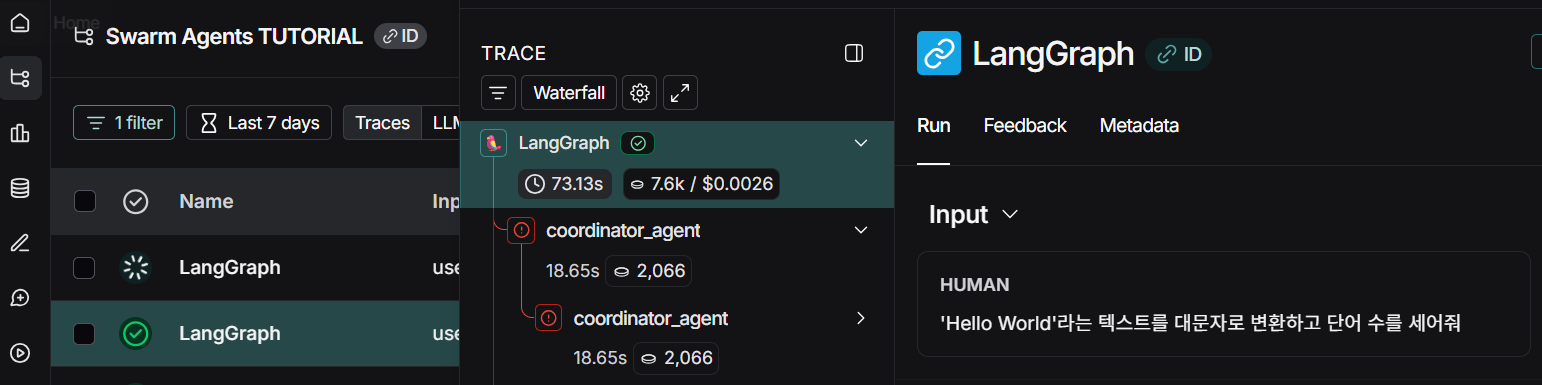

### 테스트 3: 검색 작업 (Search Agent)

In [28]:
result_search = run_swarm("Python에 대해 알려줘")


사용자: Python에 대해 알려줘

에이전트 전환 과정:
   2. [AI 응답]
   3. [transfer_to_search]
   4. [AI 응답]
   5. [search_knowledge]
   6. [AI 응답]
   7. [transfer_to_coordinator]
   8. [AI 응답]
최종 응답:
   다음은 Python에 대한 간단한 개요입니다.

- 무엇인가요
  - Python은 고급(interpreted), 범용 프로그래밍 언어로 1991년 Guido van Rossum이 만들었습니다. 이름은 Monty Python에서 따온 것으로 알려져 있습니다. 읽기 쉬운 문법과 풍부한 생태계로 다양한 분야에서 널리 사용됩니다.
  - 현재 주력 버전은 Python 3 계열이며, Python 2는 더 이상 공식적으로 지원되지 않습니다.

- 특징
  - 읽기 쉬운 문법과 들여쓰기 중심의 구조
  - 인터프리터 언어로 즉시 실행 가능, 플랫폼 간 호환성 좋음
  - 동적 타이핑, 자동 메모리 관리(가비지 컬렉션)
  - 방대한 표준 라이브러리와 서드파이 라이브러리(PyPI를 통한 설치)
  - 다중 패러다임 지원: 절차적, 객체지향, 일부 함수형 프로그래밍 요소
  - 큰 커뮤니티와 풍부한 학습 자료

- 주요 용도/분야
  - 웹 개발: Django, Flask, FastAPI 등
  - 데이터 과학/수치 계산: NumPy, Pandas, SciPy, Jupyter 노트북
  - 머신러닝/딥러닝: Scikit-learn, TensorFlow, PyTorch
  - 자동화/스크립트 작성 및 시스템 관리
  - 교육용으로 입문하기 좋음

- 시작하기 좋은 이유
  - 빠르게 프로토타이핑 가능
  - 초보자 친화적이며, 많은 학습 자료와 예제가 있음
  - 다양한 분야로의 확장성

- 간단한 예제(파이썬 3)
  - Hello, Python
    - print("Hello, Python!")
  - 간단한 합계 함수
    - def add(a

In [29]:
result_search

{'messages': [HumanMessage(content='Python에 대해 알려줘', additional_kwargs={}, response_metadata={}, id='c83f9f2b-2825-4ec6-821a-95b6e6c7f4d2'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 532, 'prompt_tokens': 364, 'total_tokens': 896, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 512, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CkhBCbFu5G7rja2pZafcz0916uEuX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b00ce-b95d-7810-bd19-f2c43a8b3d70-0', tool_calls=[{'name': 'transfer_to_search', 'args': {}, 'id': 'call_vjlyj5nFcatPHr71Hydjhb3E', 'type': 'tool_call'}], usage_metadata={'input_tokens': 364, 'output_tokens': 532, 'total_tokens': 896, 'input_token_det

#### [Langsmith](https://smith.langchain.com/)

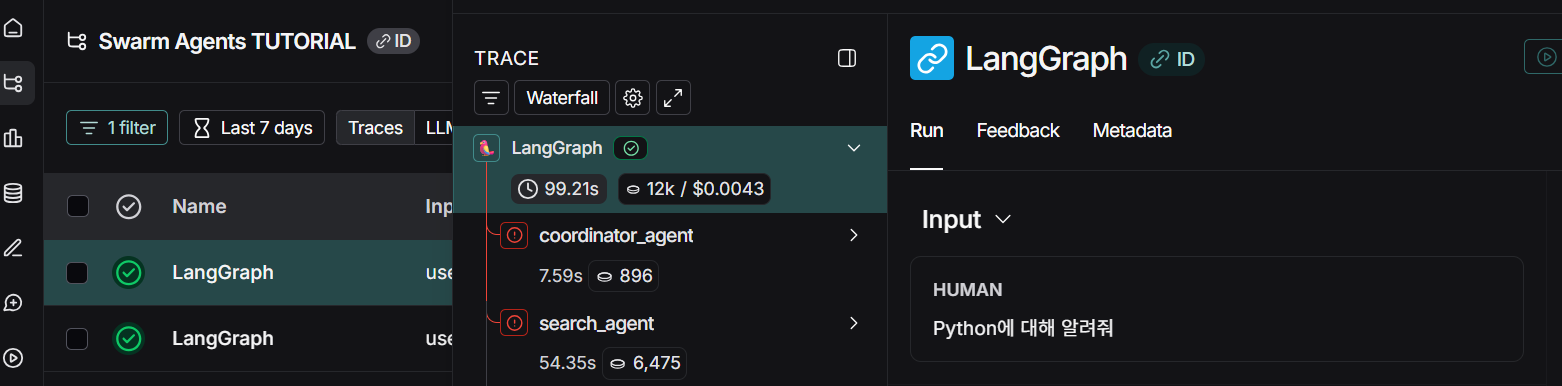